In [1]:
# Levi Félix Barbosa - 579420

# carregar e normalizar os dados

import numpy as np
import matplotlib.pyplot as plt

X = np.loadtxt('quake.csv', delimiter=',')

np.random.seed(42)

# z-score na mão, senão a escala de uma coluna domina a distância
media = X.mean(axis=0)
desvio = X.std(axis=0)
Xn = (X - media) / desvio

ks = list(range(4, 21))

In [2]:
# item a) k-médias com distância euclidiana

def kmeans_euclid(X, k, max_iter=100, tol=1e-6):
    n = X.shape[0]
    # começa com k pontos sorteados dos dados
    C = X[np.random.choice(n, k, replace=False)].copy()
    for _ in range(max_iter):
        D = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
        rot = D.argmin(axis=1)
        novoC = np.array([X[rot == j].mean(axis=0) if np.any(rot == j) else C[j]
                          for j in range(k)])
        if np.max(np.abs(novoC - C)) < tol:
            C = novoC
            break
        C = novoC
    D = ((X[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    rot = D.argmin(axis=1)
    inercia = D[np.arange(n), rot].sum()
    return C, rot, inercia


def melhor_kmeans_euclid(X, k, n_init=20):
    # roda varias vezes e fica com o de menor erro de reconstrução
    melhor = None
    for _ in range(n_init):
        C, rot, inercia = kmeans_euclid(X, k)
        if melhor is None or inercia < melhor[2]:
            melhor = (C, rot, inercia)
    return melhor


def davies_bouldin(X, C, rot):
    k = C.shape[0]
    S = np.zeros(k)   # dispersão média de cada grupo
    for i in range(k):
        pts = X[rot == i]
        S[i] = np.sqrt(((pts - C[i]) ** 2).sum(axis=1)).mean() if len(pts) else 0.0
    R = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            if i != j:
                M = np.sqrt(((C[i] - C[j]) ** 2).sum())
                R[i, j] = (S[i] + S[j]) / M if M > 0 else 0.0
    return R.max(axis=1).mean()

In [3]:
# escolhe o k pelo menor DB

dbs = []
solucoes = []
for k in ks:
    C, rot, inercia = melhor_kmeans_euclid(Xn, k)
    db = davies_bouldin(Xn, C, rot)
    dbs.append(db)
    solucoes.append((C, rot))
    print('k = %2d   DB = %.4f   inercia = %.2f' % (k, db, inercia))

melhor_k = ks[np.argmin(dbs)]
C_best, rot_best = solucoes[np.argmin(dbs)]
print('\nmelhor k =', melhor_k)

k =  4   DB = 0.6140   inercia = 723.94
k =  5   DB = 0.6193   inercia = 585.56


k =  6   DB = 0.6197   inercia = 471.19


k =  7   DB = 0.6342   inercia = 385.91


k =  8   DB = 0.6954   inercia = 320.38


k =  9   DB = 0.6517   inercia = 256.11


...

k = 16   DB = 0.6440   inercia = 110.01


k = 17   DB = 0.6012   inercia = 106.61


k = 18   DB = 0.5960   inercia = 90.68


k = 19   DB = 0.6115   inercia = 89.64


k = 20   DB = 0.6137   inercia = 87.06

melhor k = 18


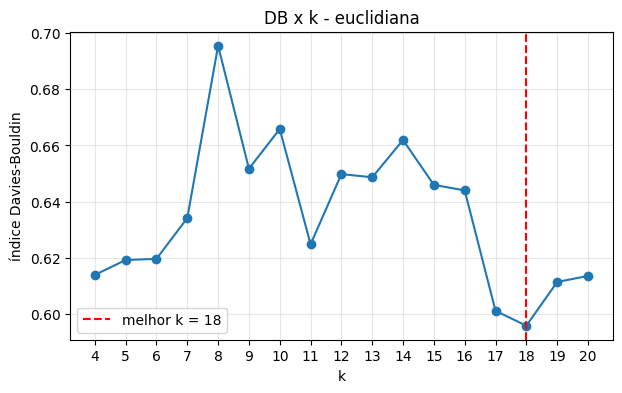

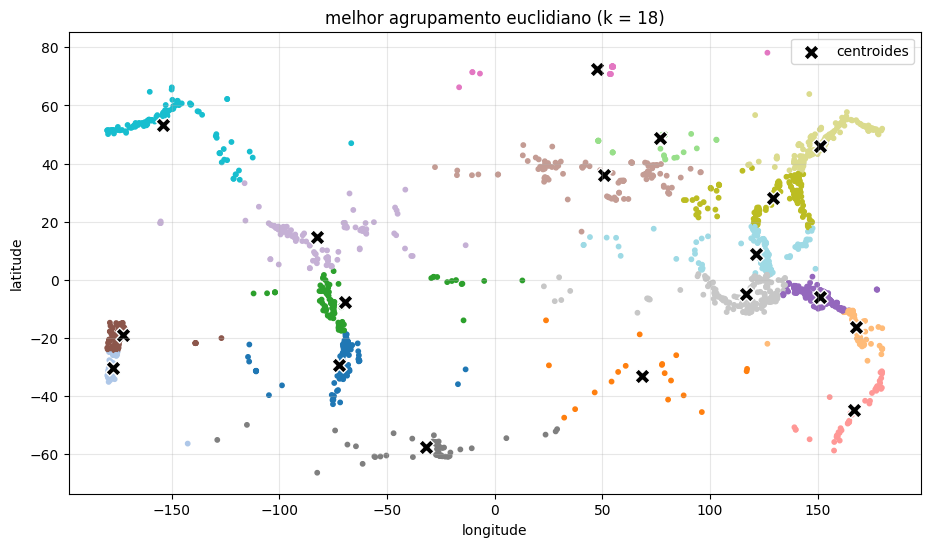

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(ks, dbs, 'o-')
plt.axvline(melhor_k, color='r', ls='--', label='melhor k = %d' % melhor_k)
plt.xlabel('k'); plt.ylabel('índice Davies-Bouldin')
plt.title('DB x k - euclidiana'); plt.xticks(ks)
plt.legend(); plt.grid(alpha=0.3); plt.show()

# plota nas coordenadas originais (longitude x latitude)
C_orig = C_best * desvio + media
plt.figure(figsize=(11, 6))
plt.scatter(X[:, 1], X[:, 0], c=rot_best, cmap='tab20', s=10)
plt.scatter(C_orig[:, 1], C_orig[:, 0], c='black', marker='X', s=120,
            edgecolors='white', label='centroides')
plt.xlabel('longitude'); plt.ylabel('latitude')
plt.title('melhor agrupamento euclidiano (k = %d)' % melhor_k)
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [5]:
# item b) agora com distância de mahalanobis, cada grupo com sua covariância

def inv_norm(S, d, reg=1e-6):
    # inversa da covariância normalizada pra det=1, senão o grupo colapsa
    S = S + reg * np.eye(d)
    S = S / (np.linalg.det(S) ** (1.0 / d))
    return np.linalg.inv(S)


def kmeans_maha(X, k, max_iter=100, reg=1e-6):
    n, d = X.shape
    C = X[np.random.choice(n, k, replace=False)].copy()
    Sig = np.array([np.eye(d) for _ in range(k)])   # covariância começa identidade
    rot = np.full(n, -1)
    D = np.zeros((n, k))
    for _ in range(max_iter):
        invs = [inv_norm(Sig[j], d, reg) for j in range(k)]
        for j in range(k):
            diff = X - C[j]
            D[:, j] = np.einsum('ni,ij,nj->n', diff, invs[j], diff)
        novo = D.argmin(axis=1)
        for j in range(k):
            pts = X[novo == j]
            if len(pts) > d:   # atualiza centroide e covariância do grupo
                C[j] = pts.mean(axis=0)
                Sig[j] = np.cov(pts.T) + reg * np.eye(d)
        if np.array_equal(novo, rot):
            break
        rot = novo
    inercia = D[np.arange(n), rot].sum()
    return C, Sig, rot, inercia


def melhor_kmeans_maha(X, k, n_init=20):
    melhor = None
    for _ in range(n_init):
        sol = kmeans_maha(X, k)
        if melhor is None or sol[3] < melhor[3]:
            melhor = sol
    return melhor


def davies_bouldin_maha(X, C, Sig, rot, reg=1e-6):
    # mesmo DB, mas com a distância de mahalanobis de cada grupo
    k, d = C.shape
    invs = [inv_norm(Sig[i], d, reg) for i in range(k)]
    S = np.zeros(k)
    for i in range(k):
        pts = X[rot == i]
        if len(pts):
            diff = pts - C[i]
            S[i] = np.sqrt(np.einsum('ni,ij,nj->n', diff, invs[i], diff)).mean()
    R = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            if i != j:
                dij = C[i] - C[j]
                # separação simétrica entre os dois centroides
                m = 0.5 * (np.sqrt(dij @ invs[i] @ dij) + np.sqrt(dij @ invs[j] @ dij))
                R[i, j] = (S[i] + S[j]) / m if m > 0 else 0.0
    return R.max(axis=1).mean()

In [6]:
# escolhe o k pelo menor DB

dbs_m = []
solucoes_m = []
for k in ks:
    C, Sig, rot, inercia = melhor_kmeans_maha(Xn, k)
    db = davies_bouldin_maha(Xn, C, Sig, rot)
    dbs_m.append(db)
    solucoes_m.append((C, rot))
    print('k = %2d   DB = %.4f   inercia = %.2f' % (k, db, inercia))

melhor_k_m = ks[np.argmin(dbs_m)]
C_best_m, rot_best_m = solucoes_m[np.argmin(dbs_m)]
print('\nmelhor k =', melhor_k_m)

k =  4   DB = 0.5471   inercia = 548.53


k =  5   DB = 0.4924   inercia = 404.80


k =  6   DB = 0.5225   inercia = 304.77


k =  7   DB = 0.4914   inercia = 254.99


k =  8   DB = 0.4527   inercia = 204.89


...

k = 16   DB = 0.5159   inercia = 76.70


k = 17   DB = 0.5075   inercia = 69.49


k = 18   DB = 0.4288   inercia = 66.84


k = 19   DB = 0.8665   inercia = 62.80


k = 20   DB = 0.5346   inercia = 54.75

melhor k = 13


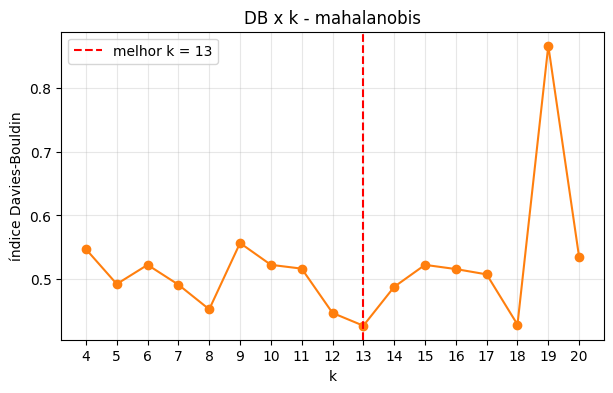

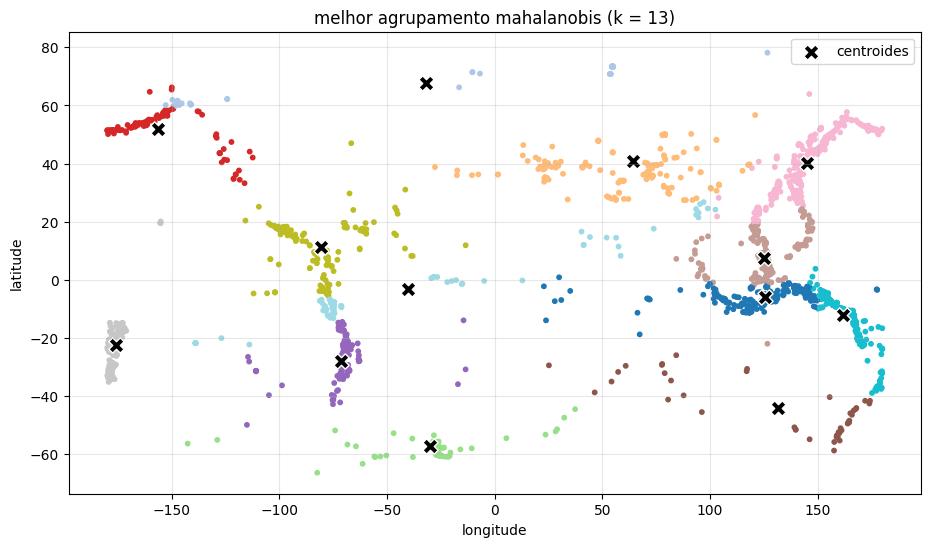

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(ks, dbs_m, 'o-', color='C1')
plt.axvline(melhor_k_m, color='r', ls='--', label='melhor k = %d' % melhor_k_m)
plt.xlabel('k'); plt.ylabel('índice Davies-Bouldin')
plt.title('DB x k - mahalanobis'); plt.xticks(ks)
plt.legend(); plt.grid(alpha=0.3); plt.show()

C_orig_m = C_best_m * desvio + media
plt.figure(figsize=(11, 6))
plt.scatter(X[:, 1], X[:, 0], c=rot_best_m, cmap='tab20', s=10)
plt.scatter(C_orig_m[:, 1], C_orig_m[:, 0], c='black', marker='X', s=120,
            edgecolors='white', label='centroides')
plt.xlabel('longitude'); plt.ylabel('latitude')
plt.title('melhor agrupamento mahalanobis (k = %d)' % melhor_k_m)
plt.legend(); plt.grid(alpha=0.3); plt.show()